# Análise da Relação entre Dados

### O mercado de shows em São Paulo (2021–2025)

##### O projeto pretende entender o comportamento e fluxo de público em shows médio e grande em São Paulo, considerando a popularidade do nome no spotify, o genero qdo nome, o local onde ocorrem os shows, valores de ingresso e data

In [1]:
%matplotlib inline

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.offsetbox import OffsetImage, AnnotationBbox
from matplotlib.colors import LinearSegmentedColormap
import matplotlib.patheffects as patheffects
import seaborn as sns
import plotly
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
from phik.report import plot_correlation_matrix
from statsmodels.nonparametric.smoothers_lowess import lowess

from PIL import Image
from io import BytesIO

import requests
from ydata_profiling import ProfileReport

## Relação entre variáveis

In [2]:
df = pd.read_csv('../data/temp/base_projeto_temp.csv', sep = ',')

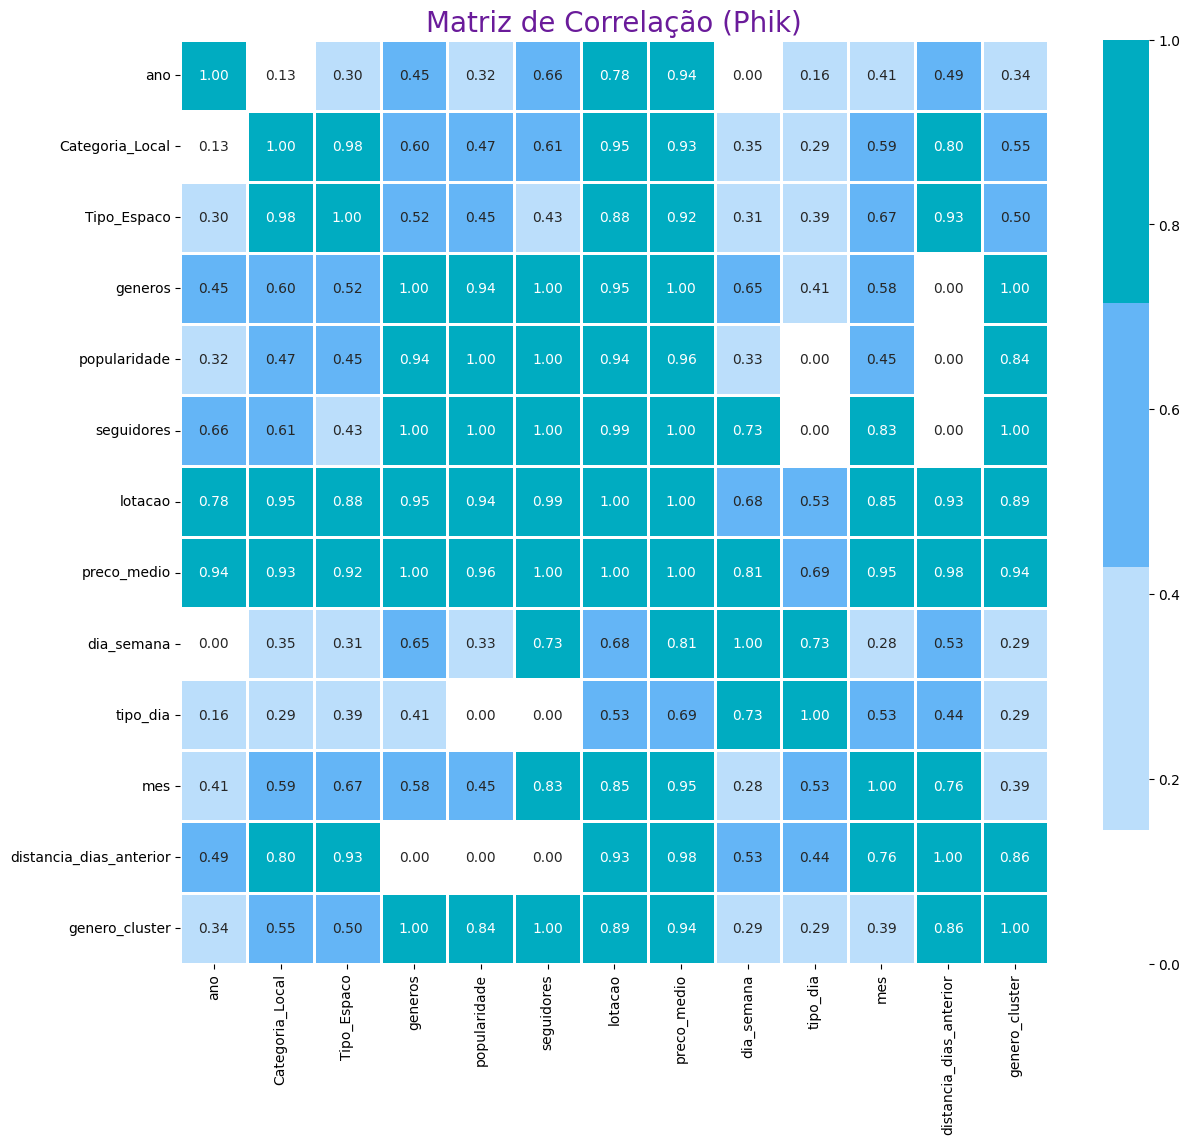

In [3]:
phik_corr = df.phik_matrix(interval_cols=[])
custom_vlag = [
    "#E91E63",  
    "#EC407A",
    "#F8BBD0",
    "#FFFFFF",  
    "#BBDEFB",
    "#64B5F6",
    "#00ACC1"   
]

plt.figure(figsize=(14, 12))
sns.heatmap(
    phik_corr,
    annot=True,
    fmt='.2f',
    cmap=custom_vlag,             
    center=0,
    linewidths=2,
    linecolor='#FFFFFF'
) 
plt.title('Matriz de Correlação (Phik)', fontsize=20, color='#6A1B9A')
plt.show()

A matriz de correlação phik indica algumas variáveis com alta associação entre si. A seguir, são apresentadas as principais relações observadas e as decisões adotadas para a modelagem:

Ano e lotação: a correlação observada está relacionada principalmente ao aumento do número de shows ao longo dos anos, conforme análises gráficas anteriores.
➝ Manter ambas.

Categoria_Local e Tipo_Espaco: ambas descrevem características do local do evento, sendo, portanto, redundantes. Como o objetivo do estudo é a determinação do público estimado para posterior escolha do local, optou-se pela retirada de ambas variáveis.
➝ Retirar ambas.

Categoria_Local e distancia_dias_anterior: apesar da correlação, não há relação conceitual direta entre as variáveis, que representam aspectos distintos do evento.
➝ Manter ambas.

Gêneros, popularidade e seguidores: correlações esperadas, dado que determinados gêneros concentram artistas mais populares. As variáveis representam conceitos distintos.
➝ Manter gêneros e popularidade;
➝ Remover seguidores, por apresentar alta correlação com popularidade e maior variabilidade.

Preço_medio: apresenta correlação elevada com diversas variáveis. Além disso, análises anteriores indicam forte dependência temporal (ano), caracterizando-se mais como consequência da demanda do que como fator explicativo do público.
➝ Remover da modelagem.

Tipo_dia e dia_semana: relação esperada, com padrões de correlação semelhantes. Tipo_dia foi mantida por possuir menos categorias e maior simplicidade interpretativa.
➝ Manter apenas tipo_dia.

gêneros × gênero_cluster: A alta correlação é esperada, pois gênero_cluster deriva de gêneros. Para reduzir a dimensionalidade e melhorar a modelagem, será mantida apenas a variável gênero_cluster
➝ Manter apenas genero_cluster.

In [4]:
df = df.drop(
    ['Tipo_Espaco', 
     'Categoria_Local',
     'seguidores',
     'preco_medio',
     'generos',
     'dia_semana'], axis = 1)
df.to_csv('../data/processed/base_modelo.csv', index=False, encoding='utf-8-sig')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 848 entries, 0 to 847
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   ano                      848 non-null    int64  
 1   popularidade             848 non-null    float64
 2   lotacao                  848 non-null    float64
 3   tipo_dia                 848 non-null    object 
 4   mes                      848 non-null    object 
 5   distancia_dias_anterior  848 non-null    float64
 6   genero_cluster           848 non-null    object 
dtypes: float64(3), int64(1), object(3)
memory usage: 46.5+ KB


## Tipo de relação das variáveis com "lotação"

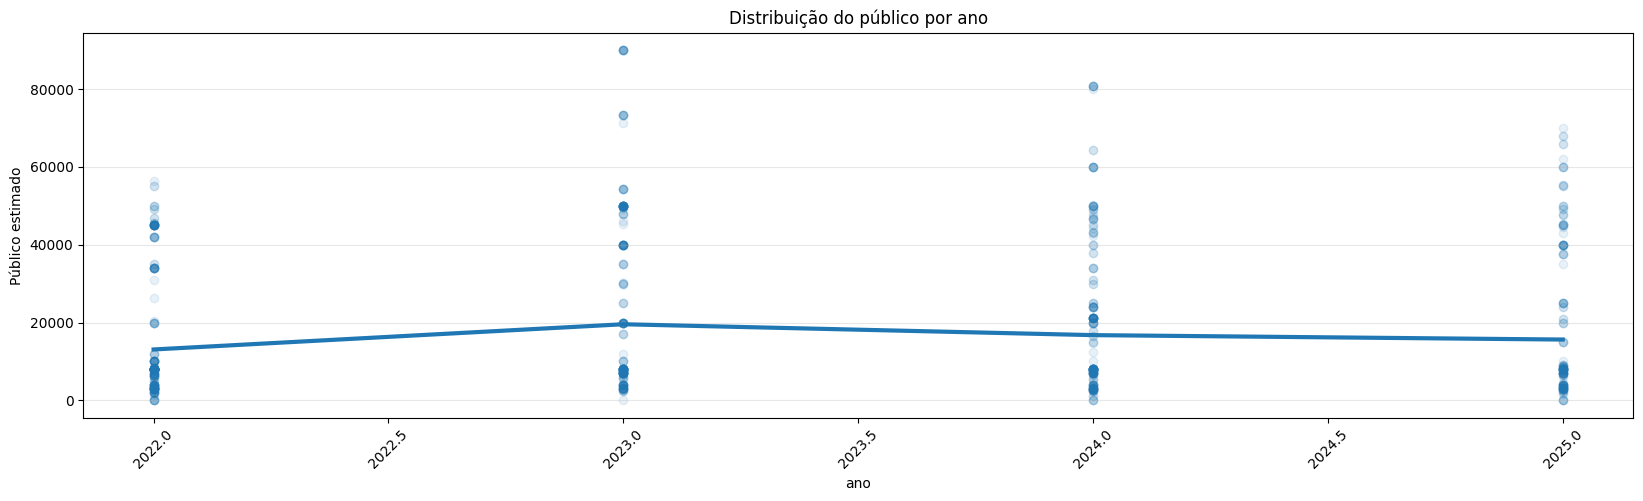

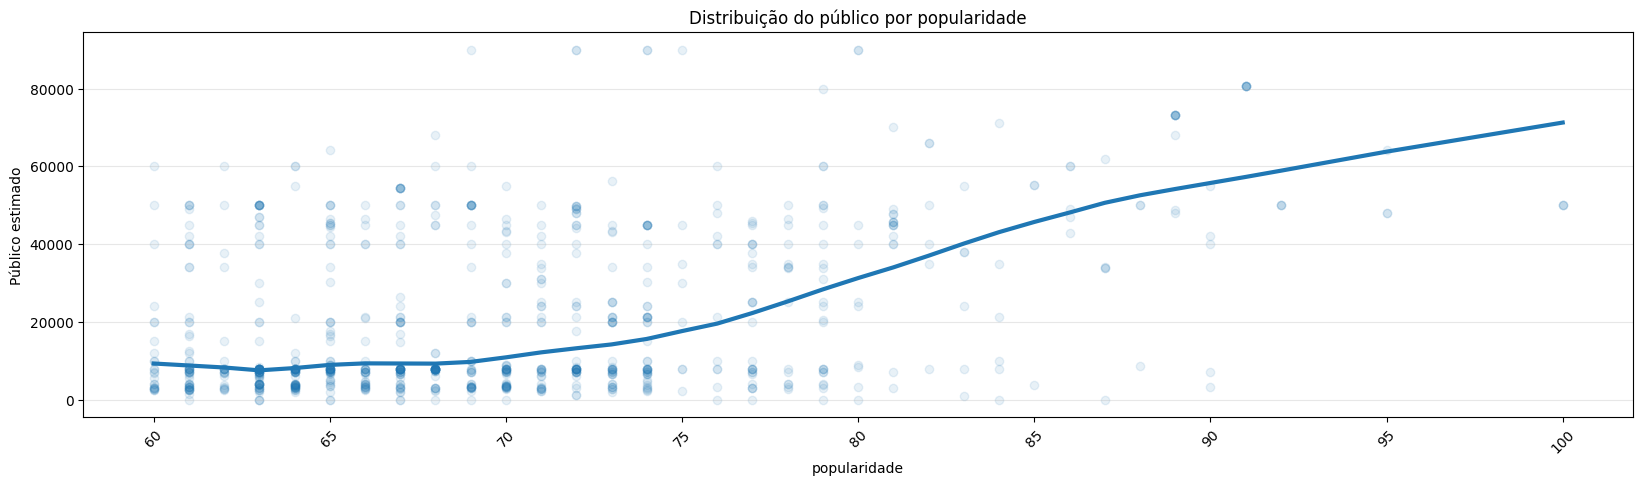

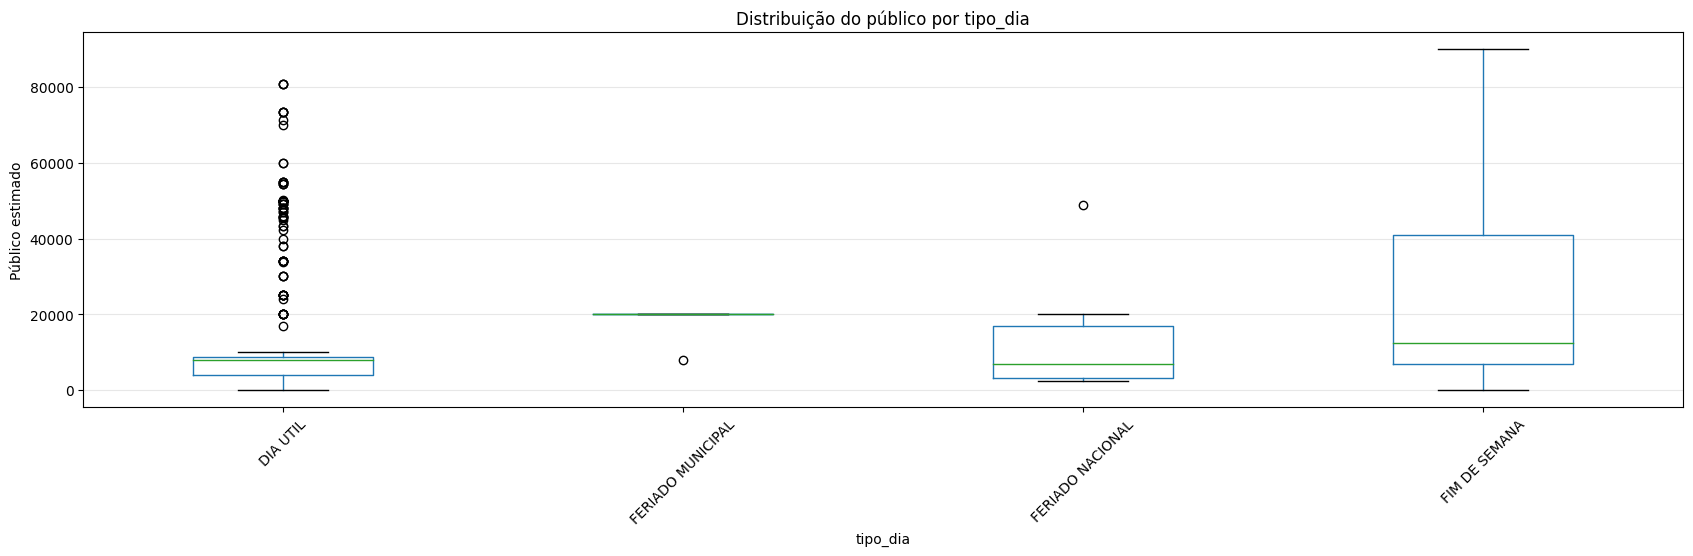

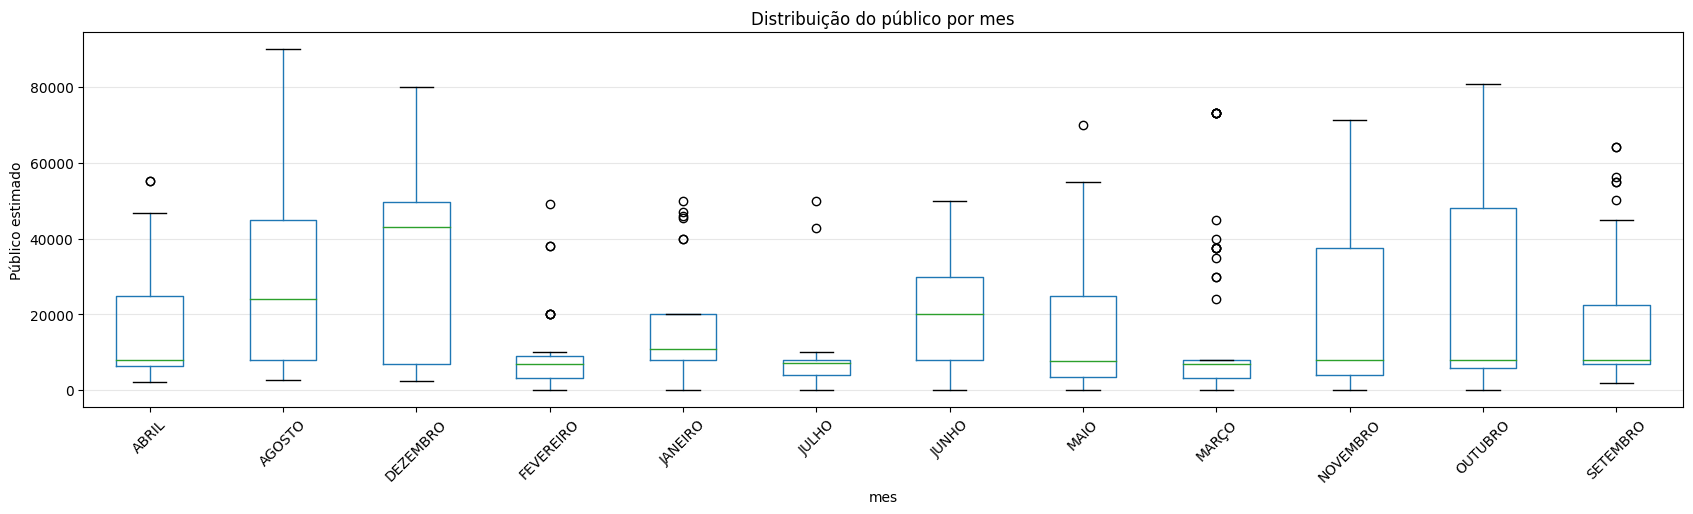

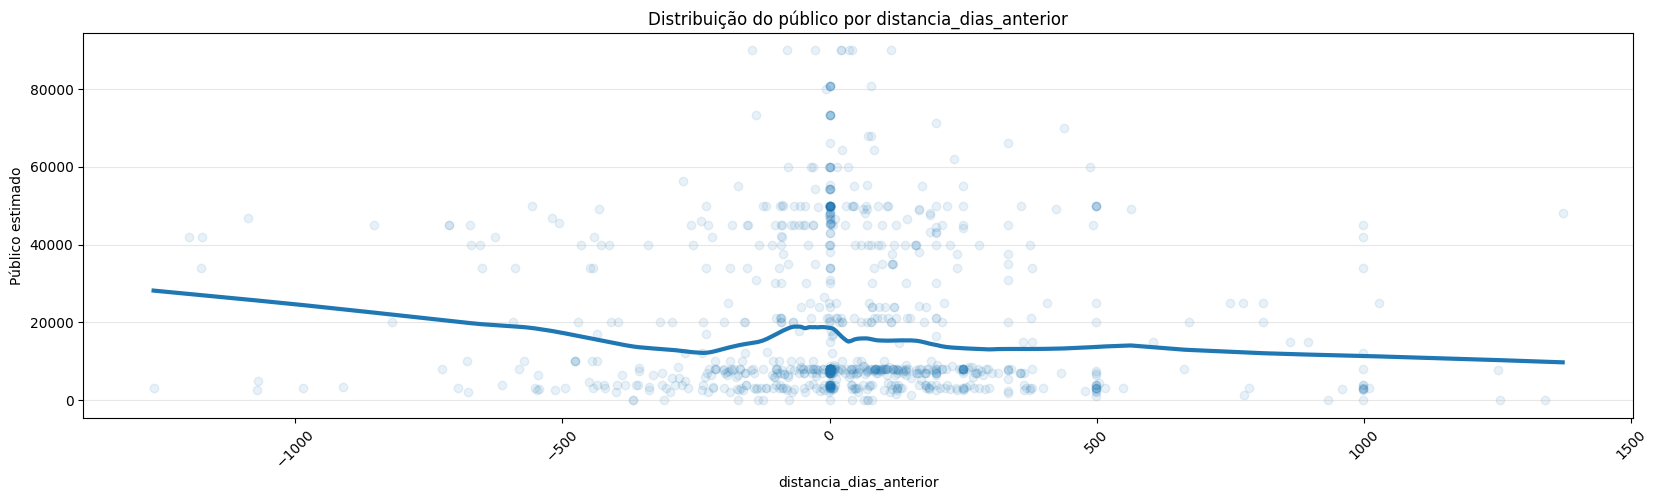

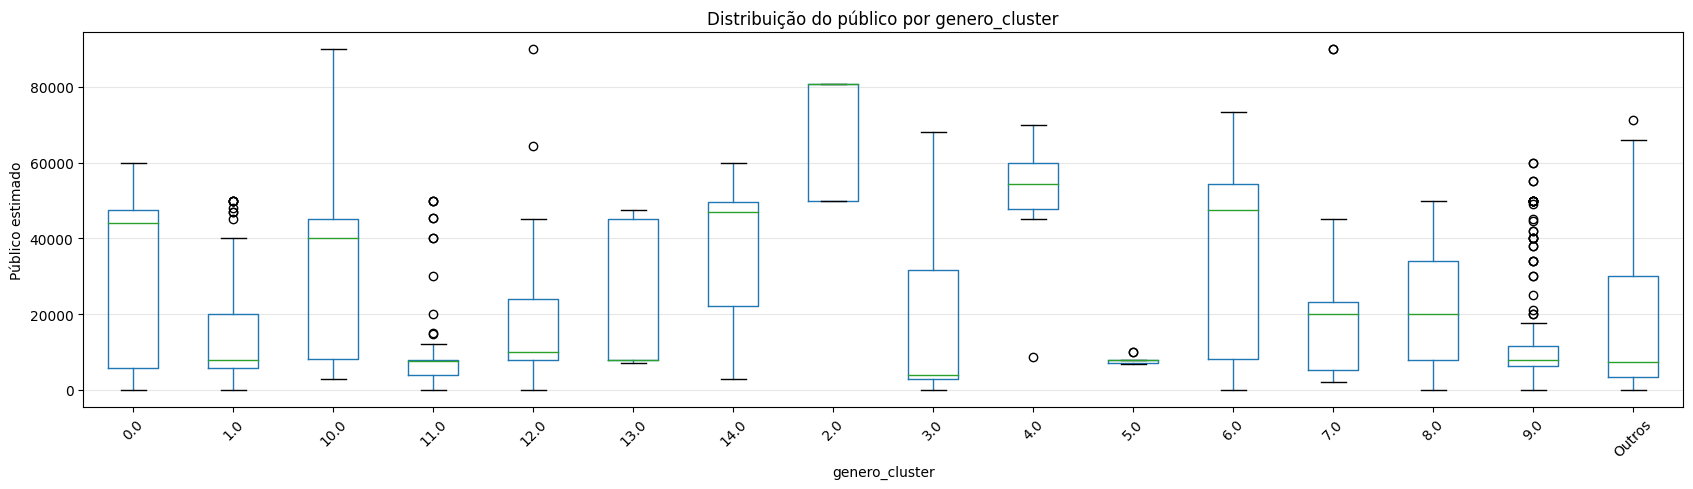

In [6]:
for col in df.columns:

    y = 'lotacao'
    if col == y:
        continue

    if df[col].dtype in ['float64', 'int64']:
        x = df[col]
        y_vals = df[y]

        plt.figure(figsize=(20,5))
        curve = lowess(y_vals, x, frac=0.3)
        plt.scatter(x, y_vals, alpha=0.1)
        plt.plot(curve[:,0], curve[:,1], linewidth=3)

    else:
        fig, ax = plt.subplots(figsize=(20,5))
        
        if col == 'generos':
            min_n = 15
            freq = df['generos'].value_counts()
            generos_validos = freq[freq >= min_n].index
            df['generos_grp'] = df['generos'].where(df['generos'].isin(generos_validos),'Outros')
            
            df.boxplot(
                column=y,
                by='generos_grp',
                grid=False,
                ax = ax
            )
            
        else:
            df.boxplot(
                column=y,
                by=col,
                grid=False,
                ax = ax
            )

    plt.suptitle('')
    plt.xlabel(col)
    plt.grid(axis='y', alpha=0.3)
    plt.ylabel('Público estimado')
    plt.title(f'Distribuição do público por {col}')
    plt.xticks(rotation=45)
    plt.show()

Com base nos gráficos apresentados, é possível caracterizar qualitativamente a forma das relações entre as variáveis explicativas selecionadas e o público estimado. Essa etapa tem caráter descritivo e busca identificar padrões funcionais que auxiliem a etapa posterior de modelagem, sem inferência causal.

        * ano: Observa-se um comportamento ondulatório, com picos e vales ao longo do tempo, semelhante a uma função periódica sempre positiva. O padrão sugere ciclos temporais associados a fatores de calendário e contexto histórico, sem tendência de crescimento monotônico.
        * popularidade: A relação apresenta forma convexa, com ganho marginal decrescente: aumentos iniciais de popularidade estão associados a maiores variações de público, enquanto níveis elevados geram incrementos mais moderados.
        * tipo_dia: A relação sugere diferenças positivas de público entre dias úteis e finais de semana, com comportamento aproximadamente linear ou levemente ondulatório.
        * mes: O padrão é claramente periódico, refletindo efeitos sazonais associados ao calendário cultural, festivais e períodos de férias.
        * distancia_dias_anterior: Observa-se uma relação positiva e aproximadamente linear, indicando que maiores intervalos entre shows de um mesmo gênero tendem a estar associados a públicos médios maiores, embora com dispersão relevante.
        * generos_cluster: A variável apresenta um padrão aproximadamente cíclico, indicando que diferentes grupos de gêneros alternam períodos de maior e menor demanda ao longo do tempo.